# SENTINEL · Notebook 2 · `sim/`

**What this notebook builds:** the **scenario engine** from slide 4:
> *SimPy · Scenario engine: casualty waves, deterioration, road closures.*

It creates the disaster that every later notebook works on:
- **Casualties** with START/SALT triage colours, arriving in **waves of reports** (the first count is far too low, just like Balasore).
- **Deterioration:** Yellow patients turn Red if nobody reaches them in time.
- **Events:** flood, road closure, hospital failure, flood worsening, building collapse, blood shortage.
- **Resources:** hospital capacities, ambulances (ALS / BLS) and donor funds.

### How to use it
Same as Notebook 1: run the grey boxes **one at a time, top to bottom**, wait for each ✅.
**Red `Error`** = stop and send Claude a screenshot. Warnings are fine.

> Everything marked *assumed* or *synthetic* is a made-up but realistic value for the demo. Real data would replace it in a pilot.

## Step 1 · Install the tools
**SimPy** is a simulation clock: it runs the disaster minute by minute and lets things "wait" and then happen.

In [13]:
!pip install -q "osmnx>=2.0,<3" folium simpy
import math, json, os, random
import networkx as nx
import osmnx as ox
import pandas as pd
import folium
import simpy
import matplotlib.pyplot as plt
print("SimPy version:", simpy.__version__)
print("✅ Step 1 done: tools installed")

SimPy version: 4.1.2
✅ Step 1 done: tools installed


## Step 2 · Load what Notebook 1 saved
A Google Drive permission pop-up will appear again: choose your account → **Allow**.

In [14]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = "/content/drive/MyDrive/SENTINEL/data"

needed = ["mumbai_roads.graphml", "hospitals.json", "area.json"]
missing = [f for f in needed if not os.path.exists(f"{DATA_DIR}/{f}")]
if missing:
    print("❌ Missing files:", missing)
    print("   Open Notebook 1, run every step including Step 10, then come back here.")
else:
    G = ox.io.load_graphml(f"{DATA_DIR}/mumbai_roads.graphml")
    with open(f"{DATA_DIR}/hospitals.json") as f:
        hospitals = json.load(f)
    with open(f"{DATA_DIR}/area.json") as f:
        area = json.load(f)
    print(f"✅ Step 2 done: loaded {G.number_of_nodes():,} junctions and {len(hospitals)} hospitals")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Step 2 done: loaded 3,609 junctions and 12 hospitals


## Step 3 · Settings
- **SEED** makes the disaster repeatable: the same number always gives the same disaster.
  In the final phase we will change it to run 30 different disasters.
- **HORIZON_MIN** is how long we simulate: the first 2 hours.

In [15]:
SEED = 42
HORIZON_MIN = 120
rng = random.Random(SEED)

CENTER = tuple(area["center"])
FLOOD_CENTER = tuple(area["flood_center"])

def straight_line_m(lat1, lon1, lat2, lon2):
    r = 6371000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp, dl = p2 - p1, math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))

def node_ll(n):
    return G.nodes[n]["y"], G.nodes[n]["x"]

def exact_labels(n, mix):
    # Turn shares like {"RED": 0.15, ...} into exactly n shuffled labels
    labels = []
    for key, share in mix.items():
        labels += [key] * round(n * share)
    biggest = max(mix, key=mix.get)
    while len(labels) < n:
        labels.append(biggest)
    labels = labels[:n]
    rng.shuffle(labels)
    return labels

def pick(mix):
    return rng.choices(list(mix), weights=list(mix.values()))[0]

print("✅ Step 3 done: seed", SEED, "| simulating", HORIZON_MIN, "minutes")

✅ Step 3 done: seed 42 | simulating 120 minutes


## Step 4 · Divide the area into 5 zones
Zone cards on slide 3 are per zone. **Z1** sits on the flood and gets the most casualties.

In [16]:
OFFSET = 0.016   # about 1.7 km
ZONES = [
    {"id": "Z1", "name": "Flood core (Mithi River)", "lat": FLOOD_CENTER[0], "lon": FLOOD_CENTER[1], "weight": 0.40},
    {"id": "Z2", "name": "North sector",      "lat": CENTER[0] + OFFSET, "lon": CENTER[1],          "weight": 0.15},
    {"id": "Z3", "name": "East sector",       "lat": CENTER[0],          "lon": CENTER[1] + OFFSET, "weight": 0.15},
    {"id": "Z4", "name": "South sector",      "lat": CENTER[0] - OFFSET, "lon": CENTER[1],          "weight": 0.15},
    {"id": "Z5", "name": "South-west sector", "lat": CENTER[0] - 0.012,  "lon": CENTER[1] - 0.014,  "weight": 0.15},
]
ZONE_RADIUS_M = 700
ZONE_BY_ID = {z["id"]: z for z in ZONES}
all_nodes = list(G.nodes)
for z in ZONES:
    dist = {n: straight_line_m(z["lat"], z["lon"], *node_ll(n)) for n in all_nodes}
    inside = [n for n in all_nodes if dist[n] <= ZONE_RADIUS_M]
    z["nodes"] = inside if len(inside) >= 20 else sorted(all_nodes, key=dist.get)[:40]
    z["center_node"] = min(all_nodes, key=dist.get)

print(pd.DataFrame([{"zone": z["id"], "name": z["name"], "share of casualties": z["weight"],
                     "junctions": len(z["nodes"])} for z in ZONES]).to_string(index=False))
print("✅ Step 4 done: 5 zones created")

zone                     name  share of casualties  junctions
  Z1 Flood core (Mithi River)                 0.40        191
  Z2             North sector                 0.15        130
  Z3              East sector                 0.15        154
  Z4             South sector                 0.15        116
  Z5        South-west sector                 0.15         88
✅ Step 4 done: 5 zones created


## Step 5 · Give each hospital a capacity *(synthetic)*
OpenStreetMap does not publish bed counts, so we assign **free disaster capacity** by hospital size.
Large public hospitals (names with *Municipal, General, Tilak, Bhabha…*) get the most.
Blood stock is split by an *assumed* Indian blood-group mix.

In [17]:
TIERS = {
    "large":  {"beds": 30, "icu": 8, "ot_per_hr": 2, "surge_pct": 20, "blood_units": 40,
               "specialties": ["general", "trauma", "burns", "dialysis", "paediatric"]},
    "medium": {"beds": 15, "icu": 4, "ot_per_hr": 1, "surge_pct": 20, "blood_units": 16,
               "specialties": ["general", "trauma", "paediatric"]},
    "small":  {"beds": 6,  "icu": 0, "ot_per_hr": 0, "surge_pct": 10, "blood_units": 0,
               "specialties": ["general"]},
}
BLOOD_MIX = {"O+": 0.36, "B+": 0.31, "A+": 0.22, "AB+": 0.06,      # assumed mix
             "O-": 0.02, "B-": 0.015, "A-": 0.01, "AB-": 0.005}
BIG_WORDS = ["municipal", "general", "tilak", "bhabha", "medical college", "government", "civil"]

for i, h in enumerate(hospitals):
    if any(w in h["name"].lower() for w in BIG_WORDS):
        tier = "large"
    else:
        tier = "medium" if rng.random() < 0.45 else "small"
    h["tier"] = tier
if not any(h["tier"] == "large" for h in hospitals):
    hospitals[0]["tier"] = "large"

for h in hospitals:
    t = TIERS[h["tier"]]
    h.update({"beds": t["beds"], "icu": t["icu"], "ot_per_hr": t["ot_per_hr"],
              "surge_pct": t["surge_pct"], "specialties": t["specialties"],
              "blood": {g: round(t["blood_units"] * s) for g, s in BLOOD_MIX.items()},
              "capacity_note": "synthetic"})

print(pd.DataFrame([{"id": h["id"], "name": h["name"][:26], "tier": h["tier"], "beds": h["beds"],
                     "ICU": h["icu"], "blood units": sum(h["blood"].values())} for h in hospitals]).to_string(index=False))
print(f"Total free beds: {sum(h['beds'] for h in hospitals)} | total ICU: {sum(h['icu'] for h in hospitals)}")
print("✅ Step 5 done: capacities assigned (synthetic)")

 id                       name   tier  beds  ICU  blood units
 H1               JOY Hospital  large    30    8           39
 H2            Inlaks Hospital medium    15    4           16
 H3  Ameeta Patil Nursing Home medium    15    4           16
 H4 Mata Ramabai B Ambedkar Ho medium    15    4           16
 H5               maa hospital  small     6    0            0
 H6         Kurla Nursing Room  small     6    0            0
 H7          new life hospital  small     6    0            0
 H8          muktabai hospital medium    15    4           16
 H9 v care hospital intensive& medium    15    4           16
H10         arpan nursing home medium    15    4           16
H11           fauziya hospital medium    15    4           16
H12            arayan hospital  small     6    0            0
Total free beds: 159 | total ICU: 36
✅ Step 5 done: capacities assigned (synthetic)


## Step 6 · Place 14 ambulances at 5 bases
- **ALS** (Advanced Life Support): can take **Red** patients, one at a time.
- **BLS** (Basic Life Support): takes up to 2 Yellow/Green patients.
Bases are placed outside the flood so the ambulances themselves are not stuck. Costs per km are *assumed*.

In [18]:
N_ALS, N_BLS, N_BASES = 5, 9, 5
safe_nodes = [n for n in all_nodes
              if straight_line_m(*FLOOD_CENTER, *node_ll(n)) > area["flood_radius_m"] + 300]
base_nodes = rng.sample(safe_nodes, N_BASES)

ambulances = []
for i, kind in enumerate(["ALS"] * N_ALS + ["BLS"] * N_BLS):
    b = base_nodes[i % N_BASES]
    lat, lon = node_ll(b)
    ambulances.append({"id": f"A{i + 1:02d}", "type": kind, "base": f"B{i % N_BASES + 1}",
                       "node": int(b), "lat": lat, "lon": lon,
                       "seats": 1 if kind == "ALS" else 2,
                       "cost_per_km": 60 if kind == "ALS" else 30})

print(pd.DataFrame(ambulances)[["id", "type", "base", "seats", "cost_per_km"]].to_string(index=False))
print(f"✅ Step 6 done: {N_ALS} ALS + {N_BLS} BLS ambulances at {N_BASES} bases")

 id type base  seats  cost_per_km
A01  ALS   B1      1           60
A02  ALS   B2      1           60
A03  ALS   B3      1           60
A04  ALS   B4      1           60
A05  ALS   B5      1           60
A06  BLS   B1      2           30
A07  BLS   B2      2           30
A08  BLS   B3      2           30
A09  BLS   B4      2           30
A10  BLS   B5      2           30
A11  BLS   B1      2           30
A12  BLS   B2      2           30
A13  BLS   B3      2           30
A14  BLS   B4      2           30
✅ Step 6 done: 5 ALS + 9 BLS ambulances at 5 bases


## Step 7 · Create the casualties
**Two groups:**
- **Flood (135 people, from minute 0):** triage mix 15% Red · 25% Yellow · 55% Green · 5% Grey (from the mass-casualty research in our deck).
- **Building collapse (25 people, at minute 75 in Zone 3):** more Red and more crush injuries that need dialysis.

**Reports arrive in waves**, so the control room only *knows* about some people at first:

| Minute | Source | Share of flood casualties reported |
|---|---|---|
| 0 | Field team | 30% |
| 20 | 108/112 calls | 30% |
| 45 | Rescue boats | 25% |
| 90 | Door-to-door search | 15% |

Each source has a **confidence** (how much we trust it). Yellow patients get a **deterioration time** (*assumed* 60–150 min after injury) after which they turn Red if not yet in hospital.

In [19]:
TRIAGE_FLOOD    = {"RED": 0.15, "YELLOW": 0.25, "GREEN": 0.55, "GREY": 0.05}
TRIAGE_COLLAPSE = {"RED": 0.30, "YELLOW": 0.40, "GREEN": 0.25, "GREY": 0.05}
SPEC_FLOOD    = {"general": 0.45, "trauma": 0.30, "paediatric": 0.15, "burns": 0.05, "dialysis": 0.05}
SPEC_COLLAPSE = {"trauma": 0.50, "dialysis": 0.25, "general": 0.15, "paediatric": 0.10}
WAVES_FLOOD    = [(0, 0.30, "Field team", 0.9), (20, 0.30, "108/112 calls", 0.7),
                  (45, 0.25, "Rescue boats", 0.85), (90, 0.15, "Door-to-door search", 0.9)]
WAVES_COLLAPSE = [(75, 0.50, "Field team", 0.9), (95, 0.50, "Rescue team", 0.85)]
N_FLOOD, N_COLLAPSE, COLLAPSE_ZONE, COLLAPSE_AT = 135, 25, "Z3", 75

def make_casualties(n, first_id, injured_at, zone_mix, triage_mix, spec_mix, waves):
    triage = exact_labels(n, triage_mix)
    zone_ids = exact_labels(n, zone_mix)
    wave_ids = exact_labels(n, {i: w[1] for i, w in enumerate(waves)})
    people = []
    for i in range(n):
        z = ZONE_BY_ID[zone_ids[i]]
        node = rng.choice(z["nodes"])
        lat, lon = node_ll(node)
        colour = triage[i]
        spec = pick(spec_mix)
        report_t, _, source, confidence = waves[wave_ids[i]]
        people.append({
            "id": f"P{first_id + i:03d}", "zone": z["id"], "node": int(node), "lat": lat, "lon": lon,
            "triage": colour, "specialty": spec, "age_group": "child" if spec == "paediatric" else "adult",
            "blood_group": pick(BLOOD_MIX),
            "blood_units": rng.randint(2, 4) if colour == "RED" else (rng.randint(0, 1) if colour == "YELLOW" else 0),
            "needs_als": colour == "RED",
            "injured_at": injured_at, "reported_at": report_t, "source": source, "confidence": confidence,
            "deteriorate_at": injured_at + rng.randint(60, 150) if colour == "YELLOW" else None,
            "cause": "flood" if injured_at == 0 else "collapse",
        })
    return people

casualties = (make_casualties(N_FLOOD, 1, 0, {z["id"]: z["weight"] for z in ZONES},
                              TRIAGE_FLOOD, SPEC_FLOOD, WAVES_FLOOD)
              + make_casualties(N_COLLAPSE, N_FLOOD + 1, COLLAPSE_AT, {COLLAPSE_ZONE: 1.0},
                                TRIAGE_COLLAPSE, SPEC_COLLAPSE, WAVES_COLLAPSE))

summary = pd.crosstab(pd.Series([c["cause"] for c in casualties], name="cause"),
                      pd.Series([c["triage"] for c in casualties], name="triage"))
print(summary.to_string())
print(f"\nKnown at minute 0: {sum(c['reported_at'] == 0 for c in casualties)} of {len(casualties)} people")
print("✅ Step 7 done: casualties created")

triage    GREEN  GREY  RED  YELLOW
cause                             
collapse      6     1    8      10
flood        74     7   20      34

Known at minute 0: 41 of 160 people
✅ Step 7 done: casualties created


## Step 8 · Schedule the disaster events
We find the **critical road**: the road segment used by the most fastest-routes from ambulance bases and zones to hospitals. Closing it hurts the most, which makes the demo honest and dramatic.

In [20]:
use_count = {}
sources = base_nodes + [z["center_node"] for z in ZONES]
hospital_nodes = {h["node"] for h in hospitals}
for s in sources:
    _, paths = nx.single_source_dijkstra(G, s, weight="travel_time")
    for hn in hospital_nodes:
        p = paths.get(hn)
        if not p:
            continue
        for u, v in zip(p[:-1], p[1:]):
            if u in hospital_nodes or v in hospital_nodes:
                continue
            key = (min(u, v), max(u, v))
            use_count[key] = use_count.get(key, 0) + 1
critical_road = max(use_count, key=use_count.get)

def dist_to_flood(h):
    return straight_line_m(h["lat"], h["lon"], *FLOOD_CENTER)
big = [h for h in hospitals if h["tier"] == "large"]
failing_hospital = min(big, key=dist_to_flood)
blood_hospital = max(hospitals, key=lambda h: sum(h["blood"].values()))

EVENTS = [
    {"t": 0,  "type": "flood", "factor": area["flood_factor"], "radius_m": area["flood_radius_m"],
     "text": f"Flood begins: roads within {area['flood_radius_m']} m of the Mithi River are {area['flood_factor']:.0f}× slower"},
    {"t": 35, "type": "road_closed", "u": int(critical_road[0]), "v": int(critical_road[1]),
     "text": f"Critical road closed (used by {use_count[critical_road]} fastest routes)"},
    {"t": 50, "type": "hospital_down", "hospital": failing_hospital["id"],
     "text": f"{failing_hospital['id']} power failure: ICU lost, beds halved"},
    {"t": 60, "type": "flood", "factor": 5.0, "radius_m": area["flood_radius_m"] + 200,
     "text": f"Flood worsens: {area['flood_radius_m'] + 200} m radius, roads 5× slower"},
    {"t": 75, "type": "collapse", "zone": COLLAPSE_ZONE,
     "text": "Building collapse in Zone 3: 25 new casualties"},
    {"t": 80, "type": "blood_shortage", "hospital": blood_hospital["id"], "group": "O+",
     "text": f"{blood_hospital['id']} runs out of O+ blood"},
]
print(pd.DataFrame(EVENTS)[["t", "text"]].rename(columns={"t": "minute"}).to_string(index=False))
print("✅ Step 8 done: events scheduled")

 minute                                                              text
      0 Flood begins: roads within 700 m of the Mithi River are 3× slower
     35                  Critical road closed (used by 24 fastest routes)
     50                           H1 power failure: ICU lost, beds halved
     60                      Flood worsens: 900 m radius, roads 5× slower
     75                    Building collapse in Zone 3: 25 new casualties
     80                                           H1 runs out of O+ blood
✅ Step 8 done: events scheduled


## Step 9 · Run the SimPy simulation (with **no response** yet)
This run shows what happens if **nobody acts**: reports trickle in, events happen and Yellow patients turn Red.
Notebook 4 will run the same disaster again *with* SENTINEL and with the nearest-hospital rule, and compare.

In [21]:
env = simpy.Environment()
timeline, snapshots = [], []
known = set()
state = {c["id"]: c["triage"] for c in casualties}

def report_wave(env, t, source, ids):
    yield env.timeout(t)
    known.update(ids)
    timeline.append((env.now, f"{len(ids)} casualties reported by {source}"))

def deterioration(env, c):
    yield env.timeout(c["deteriorate_at"])
    if state[c["id"]] == "YELLOW":          # nobody has treated them in this run
        state[c["id"]] = "RED"

def disaster_events(env):
    for ev in sorted(EVENTS, key=lambda e: e["t"]):
        yield env.timeout(ev["t"] - env.now)
        timeline.append((env.now, ev["text"]))

def snapshot(env):
    yield env.timeout(0.01)                 # let same-minute events happen first
    while True:
        exists = [c for c in casualties if c["injured_at"] <= env.now]
        snapshots.append({"minute": round(env.now), "true casualties": len(exists),
                          "known to control room": len(known),
                          "Red now": sum(state[c["id"]] == "RED" for c in exists)})
        yield env.timeout(5)

waves = {}
for c in casualties:
    waves.setdefault((c["reported_at"], c["source"]), []).append(c["id"])
for (t, source), ids in sorted(waves.items()):
    env.process(report_wave(env, t, source, ids))
for c in casualties:
    if c["deteriorate_at"] is not None:
        env.process(deterioration(env, c))
env.process(disaster_events(env))
env.process(snapshot(env))
env.run(until=HORIZON_MIN + 1)

timeline.sort(key=lambda x: x[0])
print("TIMELINE")
for t, text in timeline:
    print(f"  minute {t:>3.0f} · {text}")
turned_red = sum(1 for c in casualties if c["triage"] == "YELLOW" and state[c["id"]] == "RED")
print(f"\nWithout any response, {turned_red} Yellow patients turn Red within {HORIZON_MIN} minutes.")
print("✅ Step 9 done: SimPy simulation finished")

TIMELINE
  minute   0 · 41 casualties reported by Field team
  minute   0 · Flood begins: roads within 700 m of the Mithi River are 3× slower
  minute  20 · 40 casualties reported by 108/112 calls
  minute  35 · Critical road closed (used by 24 fastest routes)
  minute  45 · 34 casualties reported by Rescue boats
  minute  50 · H1 power failure: ICU lost, beds halved
  minute  60 · Flood worsens: 900 m radius, roads 5× slower
  minute  75 · 13 casualties reported by Field team
  minute  75 · Building collapse in Zone 3: 25 new casualties
  minute  80 · H1 runs out of O+ blood
  minute  90 · 20 casualties reported by Door-to-door search
  minute  95 · 12 casualties reported by Rescue team

Without any response, 25 Yellow patients turn Red within 120 minutes.
✅ Step 9 done: SimPy simulation finished


## Step 10 · The chart that explains the problem
The gap between the two lines is why SENTINEL keeps a **buffer U** for people not yet reported (Notebook 3).

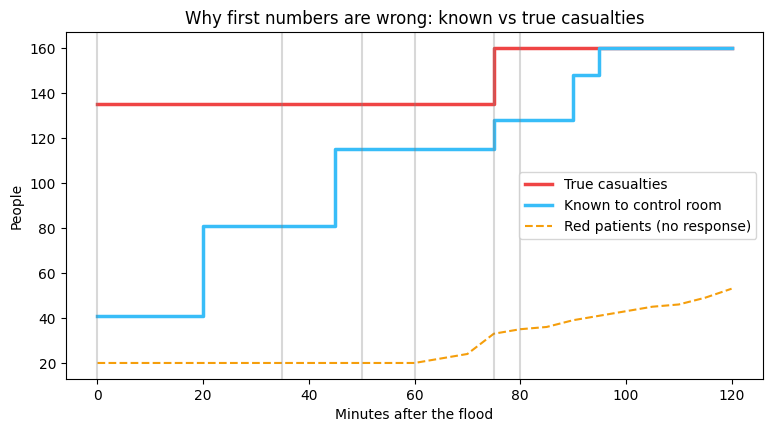

At minute 0 the control room knows 41 of 160 eventual casualties (3.9× undercount).
✅ Step 10 done


In [22]:
snap = pd.DataFrame(snapshots)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.step(snap["minute"], snap["true casualties"], where="post", label="True casualties", color="#EF4444", linewidth=2.5)
ax.step(snap["minute"], snap["known to control room"], where="post", label="Known to control room", color="#38BDF8", linewidth=2.5)
ax.plot(snap["minute"], snap["Red now"], label="Red patients (no response)", color="#F59E0B", linestyle="--")
for ev in EVENTS:
    ax.axvline(ev["t"], color="grey", alpha=0.3)
ax.set_xlabel("Minutes after the flood")
ax.set_ylabel("People")
ax.set_title("Why first numbers are wrong: known vs true casualties")
ax.legend()
plt.show()
first = snap.iloc[0]
print(f"At minute 0 the control room knows {first['known to control room']} of {snap['true casualties'].max()} eventual casualties "
      f"({snap['true casualties'].max() / max(first['known to control room'], 1):.1f}× undercount).")
print("✅ Step 10 done")

## Step 11 · See the scenario on a map
Dots are casualties coloured by triage (**dark outline** = building collapse). Red markers = hospitals (tap for capacity), blue markers = ambulance bases, black line = the critical road that will close at minute 35.

In [23]:
COLOURS = {"RED": "#EF4444", "YELLOW": "#F59E0B", "GREEN": "#22C55E", "GREY": "#64748B"}
m = folium.Map(location=CENTER, zoom_start=14, tiles="OpenStreetMap")
folium.Circle(FLOOD_CENTER, radius=area["flood_radius_m"], color="#38BDF8", fill=True,
              fill_opacity=0.2, tooltip="Flood zone (illustrative)").add_to(m)
for z in ZONES:
    folium.Circle((z["lat"], z["lon"]), radius=ZONE_RADIUS_M, color="#1E3A8A", weight=1,
                  dash_array="6", fill=False, tooltip=f"{z['id']} · {z['name']}").add_to(m)
for c in casualties:
    folium.CircleMarker((c["lat"], c["lon"]), radius=4, color="#111111" if c["cause"] == "collapse" else COLOURS[c["triage"]],
                        weight=2 if c["cause"] == "collapse" else 1, fill=True, fill_color=COLOURS[c["triage"]],
                        fill_opacity=0.9, tooltip=f"{c['id']} · {c['triage']} · {c['specialty']} · reported min {c['reported_at']}").add_to(m)
for h in hospitals:
    folium.Marker((h["lat"], h["lon"]), icon=folium.Icon(color="red", icon="plus"),
                  tooltip=f"{h['id']} · {h['name']} · {h['beds']} beds, {h['icu']} ICU ({h['tier']}, synthetic)").add_to(m)
for i, b in enumerate(base_nodes):
    folium.Marker(node_ll(b), icon=folium.Icon(color="blue", icon="road"),
                  tooltip=f"Base B{i + 1} · {sum(a['base'] == f'B{i + 1}' for a in ambulances)} ambulances").add_to(m)
u, v = critical_road
folium.PolyLine([node_ll(u), node_ll(v)], color="black", weight=10, tooltip="Critical road (closes at minute 35)").add_to(m)
m

## Step 12 · Donor funds *(synthetic)*
Every rupee is **earmarked** for a purpose. The optimiser must respect earmarks (slide 4: *fund earmarks*), and the ledger (Notebook 5) will trace each rupee to a delivery.
Donor names are pseudonymous (slide 3: *no personal data*).

In [24]:
DONATIONS = [
    {"id": "DN-01", "donor": "CSR donor A",         "amount": 1500000, "earmark": "treatment"},
    {"id": "DN-02", "donor": "NGO B",               "amount": 800000,  "earmark": "blood"},
    {"id": "DN-03", "donor": "Citizens UPI pool",   "amount": 600000,  "earmark": "transport"},
    {"id": "DN-04", "donor": "CSR donor C",         "amount": 1200000, "earmark": "treatment"},
    {"id": "DN-05", "donor": "State relief fund",   "amount": 900000,  "earmark": "any"},
]
UNIT_COSTS = {   # assumed costs in rupees
    "treatment": {"RED": 60000, "YELLOW": 20000, "GREEN": 3000, "GREY": 10000},
    "blood_per_unit": 1500,
    "transport_per_km": {"ALS": 60, "BLS": 30},
}
funds = pd.DataFrame(DONATIONS).groupby("earmark")["amount"].sum()
print((funds / 100000).round(1).astype(str).add(" lakh").to_string())
print(f"Total: ₹{sum(d['amount'] for d in DONATIONS) / 100000:.0f} lakh")
print("✅ Step 12 done: funds ready")

earmark
any           9.0 lakh
blood         8.0 lakh
transport     6.0 lakh
treatment    27.0 lakh
Total: ₹50 lakh
✅ Step 12 done: funds ready


## Step 13 · Save the scenario
Everything goes into one file, **scenario.json**, in Google Drive → SENTINEL → data.

In [25]:
scenario = {
    "seed": SEED, "horizon_min": HORIZON_MIN,
    "zones": [{k: v for k, v in z.items() if k != "nodes"} for z in ZONES],
    "zone_radius_m": ZONE_RADIUS_M,
    "hospitals": hospitals,
    "ambulances": ambulances,
    "bases": [{"id": f"B{i + 1}", "node": int(b), "lat": node_ll(b)[0], "lon": node_ll(b)[1]} for i, b in enumerate(base_nodes)],
    "casualties": casualties,
    "events": EVENTS,
    "donations": DONATIONS,
    "unit_costs": UNIT_COSTS,
    "no_response_snapshots": snapshots,
    "assumptions": [
        "Hospital capacities, blood stock, ambulance positions and costs are synthetic",
        "Triage mix 15/25/55/5 from published mass-casualty data; collapse mix assumed",
        "Yellow patients deteriorate to Red 60–150 min after injury if untreated (assumed)",
        "Report waves and source confidence values are assumed",
    ],
}
with open(f"{DATA_DIR}/scenario.json", "w") as f:
    json.dump(scenario, f, indent=1)
print(f"✅ Step 13 done: scenario.json saved ({os.path.getsize(f'{DATA_DIR}/scenario.json') / 1000:.0f} KB)")
print("🎉 Notebook 2 complete. Send Claude screenshots of Step 9 (timeline), Step 10 (chart) and Step 11 (map).")

✅ Step 13 done: scenario.json saved (76 KB)
🎉 Notebook 2 complete. Send Claude screenshots of Step 9 (timeline), Step 10 (chart) and Step 11 (map).


## What you just built (say this to a judge)
> *"Our scenario engine uses SimPy, a discrete-event simulation library. It runs the first two hours of a Mumbai flood minute by minute: casualties are reported in waves, so the control room only knows a quarter of them at first; untreated Yellow patients deteriorate to Red; and events like a road closure, a hospital power failure and a building collapse happen on a timeline. Every later step re-plans against this changing picture."*

| Slide says | Where |
|---|---|
| SimPy scenario engine | Step 9 |
| Casualty waves | Steps 7 and 9 (report waves + building collapse) |
| Deterioration | Step 7 (`deteriorate_at`) and Step 9 |
| Road closures | Step 8 (critical road) |
| START/SALT triage counts, source confidence | Step 7 |
| ALS for Red, blood-group stock, fund earmarks (data) | Steps 5, 6, 7, 12 |